In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [7]:
print(df.shape)
print(df.dtypes)

(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [8]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [9]:
df["passed"].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [10]:
subjects = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df["passed"] == 1][subjects].mean()
fail_avg = df[df["passed"] == 0][subjects].mean()

print("Pass:\n", pass_avg)
print("\nFail:\n", fail_avg)

Pass:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Fail:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [11]:
df["avg_score"] = df[subjects].mean(axis=1)

top_student = df.loc[df["avg_score"].idxmax()]
print(top_student)

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
avg_score               94.0
Name: 3, dtype: object


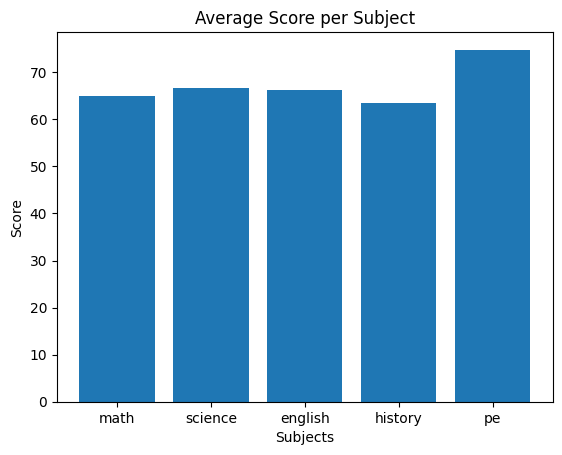

In [12]:
avg_scores = df[subjects].mean()

plt.figure()
plt.bar(subjects, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

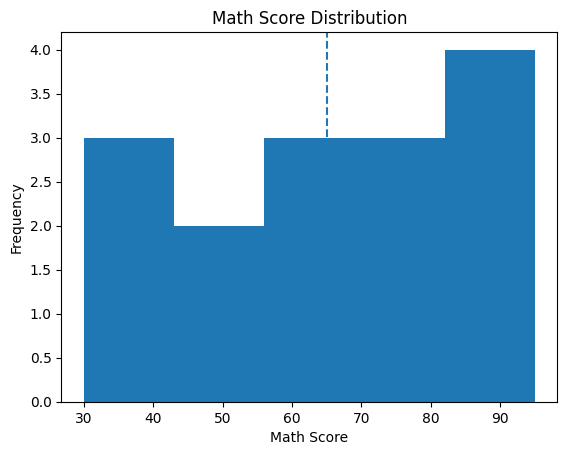

In [13]:
plt.figure()
plt.hist(df["math"], bins=5)

mean_val = df["math"].mean()
plt.axvline(mean_val, linestyle="dashed")

plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hist.png")
plt.show()

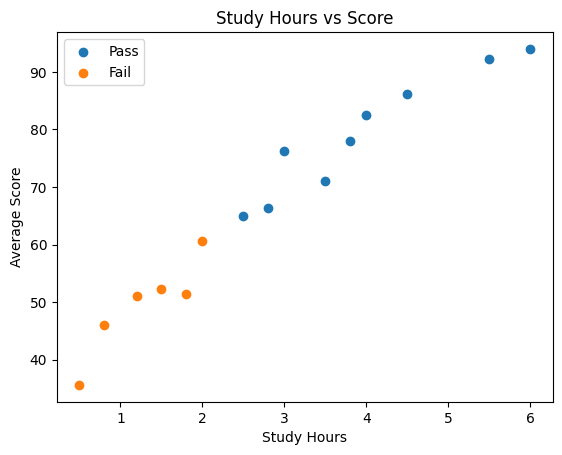

In [14]:
pass_df = df[df["passed"] == 1]
fail_df = df[df["passed"] == 0]

plt.figure()
plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], label="Fail")

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study Hours vs Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\saksh\AppData\Local\Temp\ipykernel_46224\628665228.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])


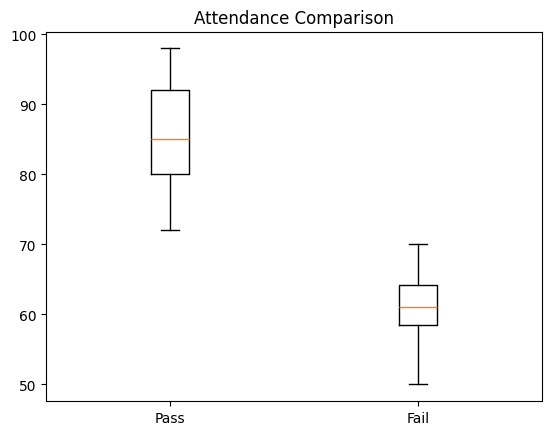

In [15]:
pass_att = df[df["passed"] == 1]["attendance_pct"]
fail_att = df[df["passed"] == 0]["attendance_pct"]

plt.figure()
plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])
plt.title("Attendance Comparison")

plt.savefig("plot4_box.png")
plt.show()

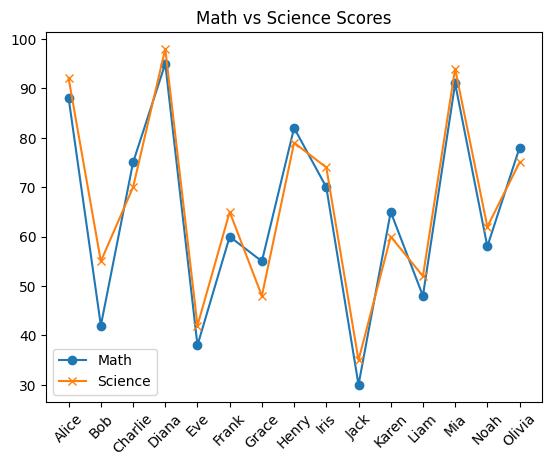

In [16]:
plt.figure()
plt.plot(df["name"], df["math"], marker='o', label="Math")
plt.plot(df["name"], df["science"], marker='x', label="Science")

plt.xticks(rotation=45)
plt.title("Math vs Science Scores")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

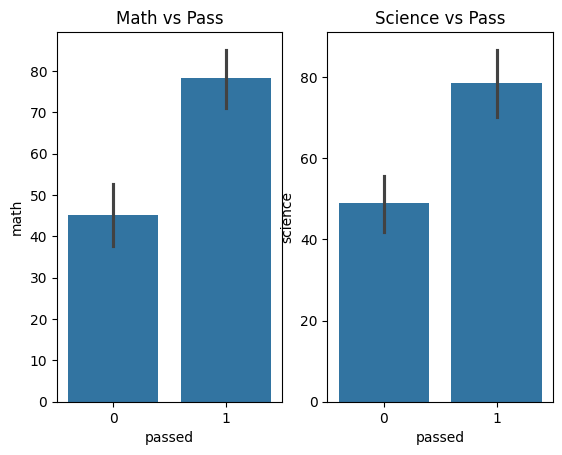

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2)

sns.barplot(data=df, x="passed", y="math", ax=ax1)
ax1.set_title("Math vs Pass")

sns.barplot(data=df, x="passed", y="science", ax=ax2)
ax2.set_title("Science vs Pass")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

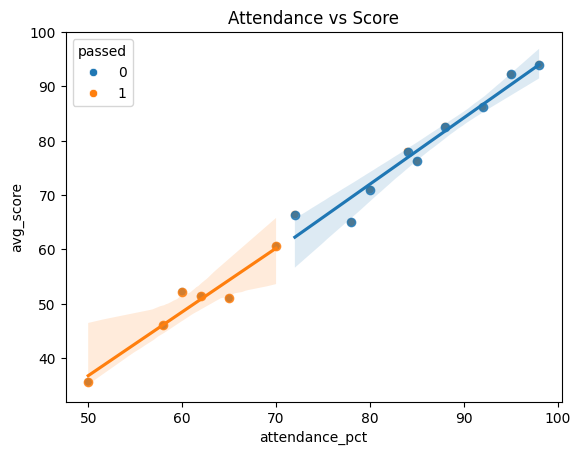

In [18]:
plt.figure()

sns.scatterplot(data=df, x="attendance_pct", y="avg_score", hue="passed")

sns.regplot(data=df[df["passed"]==1], x="attendance_pct", y="avg_score")
sns.regplot(data=df[df["passed"]==0], x="attendance_pct", y="avg_score")

plt.title("Attendance vs Score")

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [19]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training Accuracy:", model.score(X_train_scaled, y_train))

Training Accuracy: 1.0


In [21]:
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", model.score(X_test_scaled, y_test))

Test Accuracy: 1.0


In [22]:
names = df.loc[X_test.index, "name"]

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅" if actual == pred else "❌"
    print(name, actual, pred, result)

Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅


In [23]:
features = X.columns
coeff = model.coef_[0]

feature_importance = list(zip(features, coeff))
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

for f, c in feature_importance:
    print(f, c)

english 0.8125127982724647
attendance_pct 0.521876340433209
study_hours_per_day 0.4844326627100155
pe 0.47497406284967786
math 0.4379439308687359
science 0.3230097624690249
history 0.26292892629062437


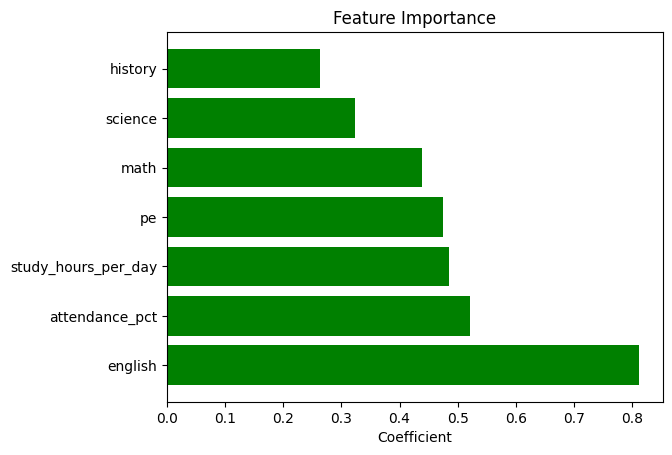

In [24]:
names = [f for f, _ in feature_importance]
values = [c for _, c in feature_importance]

colors = ["green" if v > 0 else "red" for v in values]

plt.figure()
plt.barh(names, values, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient")

plt.savefig("plot8_feature_importance.png")
plt.show()

In [25]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")
print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


c:\Users\saksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
